# 1. Median Income Map
Imported Packages

In [319]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(pd.__version__)
print(np.__version__)

3.0.3
2.5.0


In [320]:
import sys
print(sys.executable)

c:\Users\saraz\anaconda3\envs\pandas\python.exe


In [321]:
df = pd.read_csv('tarrant_income.csv')

In [322]:
import shapely
import numpy as np
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"

import os
os.listdir()

['cleaned_tarrant_snap_data.csv',
 'clean_tarrant_snap_data.ipynb',
 'mapping_tarrant_snap.ipynb',
 'snap_retailer_location_data.csv',
 'tarrantcountyanalysis.ipynb',
 'tarrantmobility_columnnames.csv',
 'tarrantmobility_data.csv',
 'tarrantmobility_tablenotes.txt',
 'tarrant_heat_maps.ipynb',
 'tarrant_heat_maps_updated.ipynb',
 'tarrant_income.csv',
 'tarrant_income_column_names.csv',
 'tarrant_income_notes.txt',
 'tarrant_metropolitan.csv',
 'tarrant_metropolitan_income.csv',
 'tarrant_poverty_tracts.csv',
 'tarrant_SNAP_data.csv',
 'tarrant_SNAP_data_column_names.csv',
 'tarrant_SNAP_data_notes.txt',
 'Tarrant_snap_map.png',
 'tl_2024_48_tract.cpg',
 'tl_2024_48_tract.dbf',
 'tl_2024_48_tract.prj',
 'tl_2024_48_tract.shp',
 'tl_2024_48_tract.shp.ea.iso.xml',
 'tl_2024_48_tract.shp.iso.xml',
 'tl_2024_48_tract.shx']

In [323]:
import sys
!{sys.executable} -m pip install shapely

In [324]:
import shapely

In [325]:
import sys
!{sys.executable} -m pip uninstall matplotlib -y
!{sys.executable} -m pip install matplotlib --no-cache-dir

Found existing installation: matplotlib 3.11.0


error: uninstall-no-record-file

× Cannot uninstall matplotlib 3.11.0
╰─> The package's contents are unknown: no RECORD file was found for matplotlib.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps matplotlib==3.11.0


In [326]:
import sys
!{sys.executable} -m pip install shapely geopandas fiona pyproj pyogrio

In [327]:
import sys
print(sys.executable)

c:\Users\saraz\anaconda3\envs\pandas\python.exe


In [328]:
import sys
!{sys.executable} -m pip uninstall matplotlib -y
!{sys.executable} -m pip uninstall matplotlib-inline -y
!{sys.executable} -m pip install matplotlib matplotlib-inline --force-reinstall --no-cache-dir

Found existing installation: matplotlib 3.11.0


error: uninstall-no-record-file

× Cannot uninstall matplotlib 3.11.0
╰─> The package's contents are unknown: no RECORD file was found for matplotlib.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps matplotlib==3.11.0


Found existing installation: matplotlib-inline 0.2.2
Uninstalling matplotlib-inline-0.2.2:
  Successfully uninstalled matplotlib-inline-0.2.2
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ----------------- ---------------------- 4.2/9.3 MB 20.9 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.3 MB 20.8 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 20.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 22.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   ---------------- ----------------------- 5.2/12.4 MB 24.5 MB/s eta 0:00:01
   -------------------------------- ------- 10.0/12.4 MB 24.8 MB/s eta 0:00:01
   ---------------------------------------- 12.4/12.4 MB 24.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ----------------------------- ----

error: uninstall-no-record-file

× Cannot uninstall matplotlib 3.11.0
╰─> The package's contents are unknown: no RECORD file was found for matplotlib.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps matplotlib==3.11.0


In [329]:
import sys
print(sys.executable)

c:\Users\saraz\anaconda3\envs\pandas\python.exe


In [330]:
import matplotlib.pyplot as plt

SHP File

In [331]:
gdf = gpd.read_file("tl_2024_48_tract.shp")

In [332]:
gdf.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,48,157,674100,48157674100,1400000US48157674100,6741,Census Tract 6741,G5020,S,4170615,0,+29.5791692,-095.5995891,"POLYGON ((-95.61467 29.57828, -95.61339 29.578..."
1,48,157,674200,48157674200,1400000US48157674200,6742,Census Tract 6742,G5020,S,5800266,189859,+29.5713421,-095.6222174,"POLYGON ((-95.63989 29.58625, -95.63974 29.586..."
2,48,441,013501,48441013501,1400000US48441013501,135.01,Census Tract 135.01,G5020,S,866463520,4539887,+32.1806265,-099.9286588,"POLYGON ((-100.15192 32.08412, -100.15188 32.0..."
3,48,441,013602,48441013602,1400000US48441013602,136.02,Census Tract 136.02,G5020,S,665184779,422010,+32.3991003,-100.0146292,"POLYGON ((-100.14955 32.2816, -100.1495 32.286..."
4,48,441,013601,48441013601,1400000US48441013601,136.01,Census Tract 136.01,G5020,S,36492558,0,+32.4639334,-100.0041804,"POLYGON ((-100.03974 32.48854, -100.03064 32.4..."


Tarrant County

In [333]:
tarrant = gdf[gdf["COUNTYFP"] == "439"]
tarrant

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
11,48,439,113906,48439113906,1400000US48439113906,1139.06,Census Tract 1139.06,G5020,S,13129842,77256,+32.9589990,-097.1707789,"POLYGON ((-97.18583 32.96026, -97.18583 32.960..."
12,48,439,113946,48439113946,1400000US48439113946,1139.46,Census Tract 1139.46,G5020,S,1593979,4850,+32.8967277,-097.2808650,"POLYGON ((-97.28964 32.89419, -97.28962 32.897..."
13,48,439,113945,48439113945,1400000US48439113945,1139.45,Census Tract 1139.45,G5020,S,2044075,894,+32.9432951,-097.2600590,"POLYGON ((-97.27254 32.9401, -97.27247 32.9408..."
14,48,439,113953,48439113953,1400000US48439113953,1139.53,Census Tract 1139.53,G5020,S,15750057,75231,+32.9685473,-097.2310989,"POLYGON ((-97.25501 32.94323, -97.255 32.94608..."
15,48,439,113955,48439113955,1400000US48439113955,1139.55,Census Tract 1139.55,G5020,S,10214459,1160334,+32.9774782,-097.1401988,"POLYGON ((-97.1681 32.98373, -97.16808 32.9846..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6724,48,439,103601,48439103601,1400000US48439103601,1036.01,Census Tract 1036.01,G5020,S,2043177,0,+32.7261058,-097.2474764,"POLYGON ((-97.25745 32.72469, -97.25741 32.727..."
6725,48,439,113404,48439113404,1400000US48439113404,1134.04,Census Tract 1134.04,G5020,S,3405856,0,+32.8313559,-097.1760082,"POLYGON ((-97.18644 32.82557, -97.18644 32.825..."
6743,48,439,122100,48439122100,1400000US48439122100,1221,Census Tract 1221,G5020,S,4336622,0,+32.7323231,-097.0832312,"POLYGON ((-97.09748 32.73074, -97.09747 32.731..."
6797,48,439,104503,48439104503,1400000US48439104503,1045.03,Census Tract 1045.03,G5020,S,1675746,0,+32.6914408,-097.3261499,"POLYGON ((-97.33176 32.6848, -97.33175 32.6848..."


Merging Median Income and Map Files

In [334]:
merged = tarrant.merge(
    df,
    left_on = "GEOIDFQ",
    right_on = "GEO_ID",
    how = "left"
)
merged

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME_x,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,S1903_C03_036E,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M
0,48,439,113906,48439113906,1400000US48439113906,1139.06,Census Tract 1139.06,G5020,S,13129842,...,-,**,-,**,-,**,-,**,-,**
1,48,439,113946,48439113946,1400000US48439113946,1139.46,Census Tract 1139.46,G5020,S,1593979,...,78010,67353,"250,000+",***,-,**,-,**,-,**
2,48,439,113945,48439113945,1400000US48439113945,1139.45,Census Tract 1139.45,G5020,S,2044075,...,91042,74668,-,**,121437,37388,-,**,-,**
3,48,439,113953,48439113953,1400000US48439113953,1139.53,Census Tract 1139.53,G5020,S,15750057,...,-,**,-,**,"250,000+",***,"250,000+",***,-,**
4,48,439,113955,48439113955,1400000US48439113955,1139.55,Census Tract 1139.55,G5020,S,10214459,...,-,**,-,**,-,**,-,**,-,**
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,48,439,103601,48439103601,1400000US48439103601,1036.01,Census Tract 1036.01,G5020,S,2043177,...,-,**,-,**,43313,10451,28920,12149,51471,14747
445,48,439,113404,48439113404,1400000US48439113404,1134.04,Census Tract 1134.04,G5020,S,3405856,...,26250,8987,-,**,58672,28472,46238,11321,83653,690
446,48,439,122100,48439122100,1400000US48439122100,1221,Census Tract 1221,G5020,S,4336622,...,29462,7358,-,**,46935,42660,65347,52120,-,**
447,48,439,104503,48439104503,1400000US48439104503,1045.03,Census Tract 1045.03,G5020,S,1675746,...,-,**,-,**,19602,11300,18295,7271,-,**


In [335]:
merged["S1903_C03_001E"] = pd.to_numeric(
    merged["S1903_C03_001E"],
    errors="coerce"
)

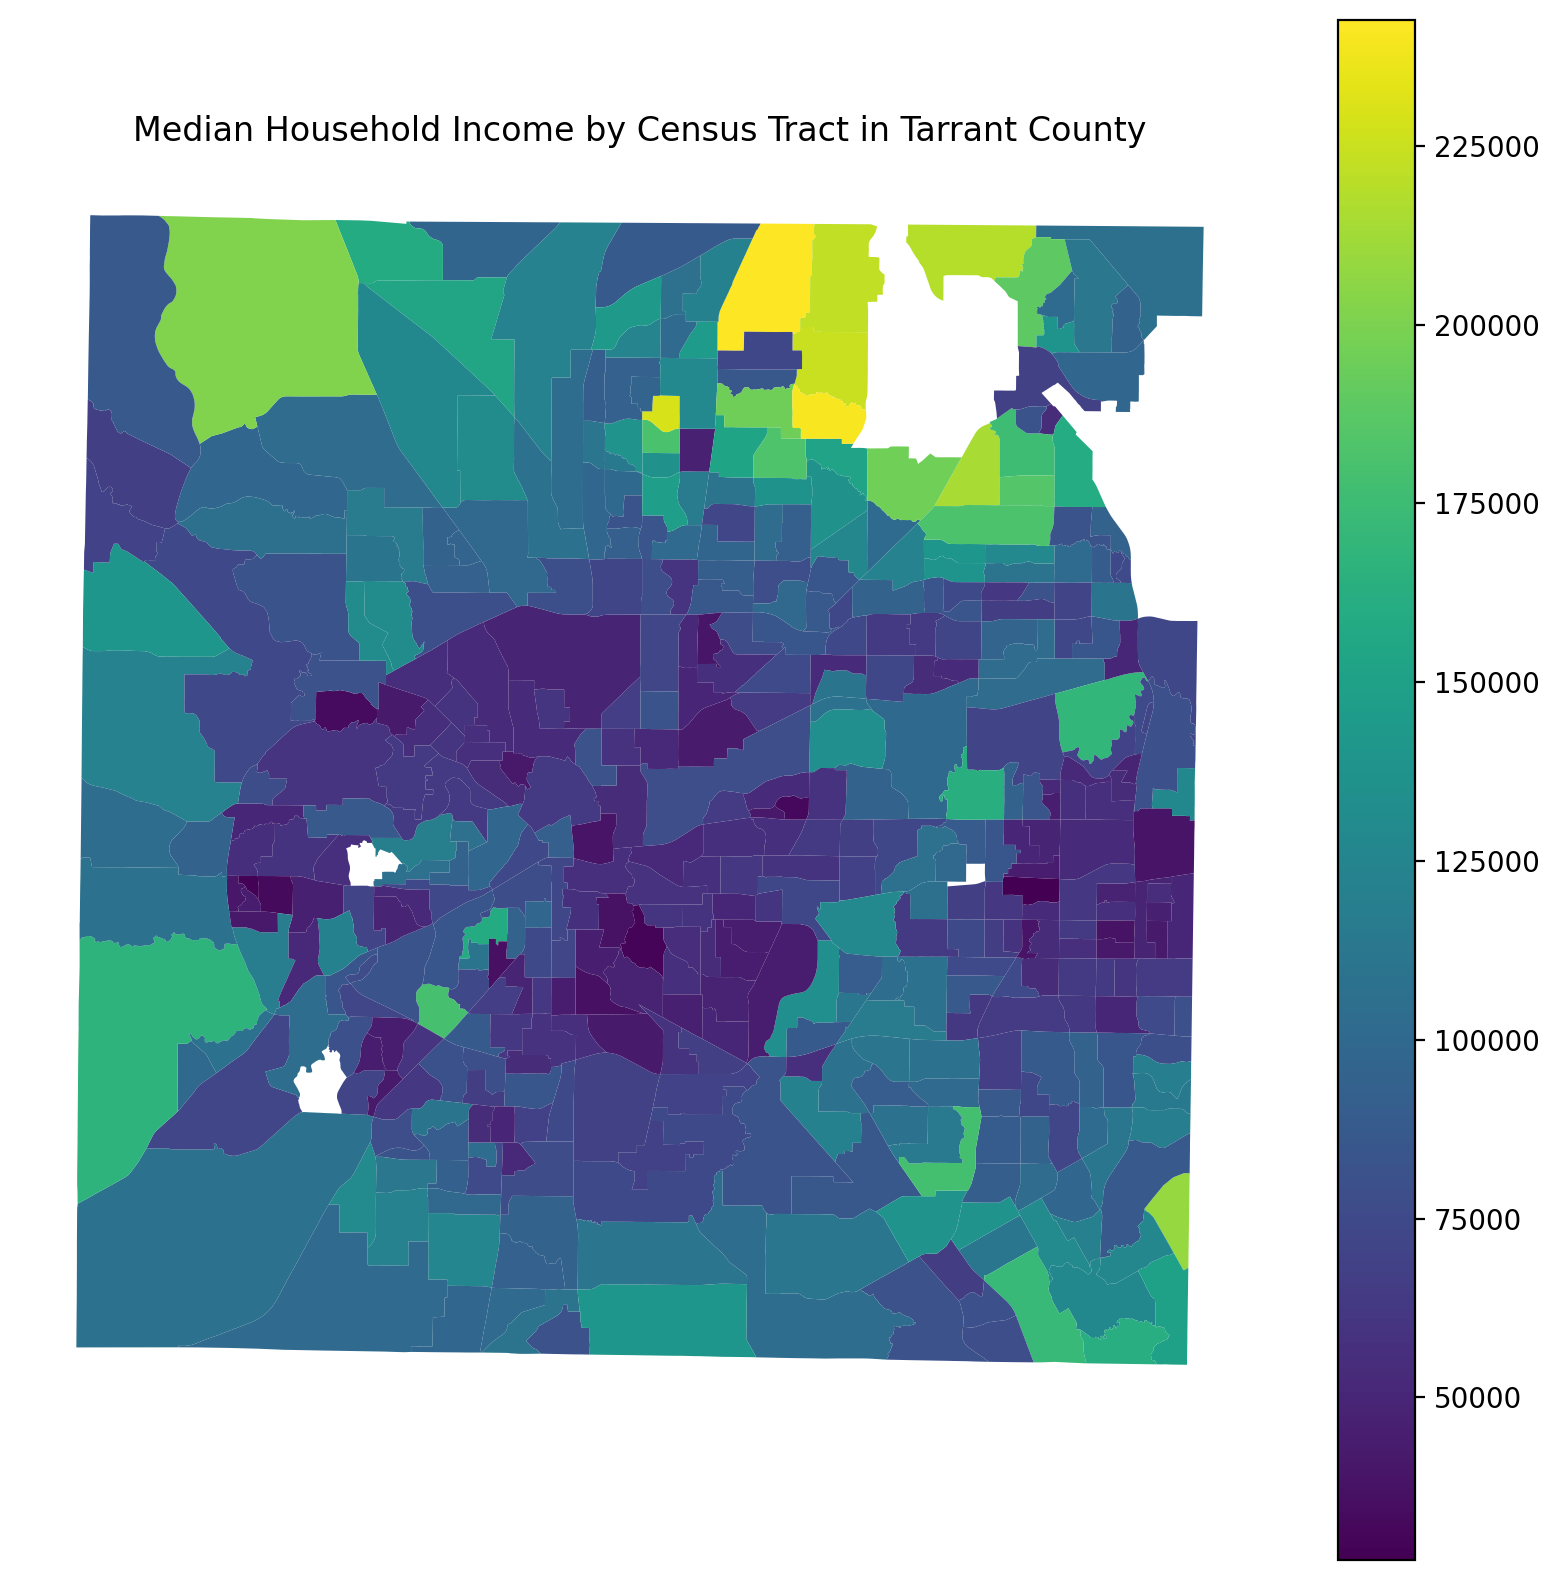

In [336]:
fig, ax = plt.subplots(figsize=(10,10))

merged.plot(
    column = "S1903_C03_001E",
    cmap = "viridis",
    legend = True,
    ax=ax
) 

plt.title("Median Household Income by Census Tract in Tarrant County")
plt.axis("off")
plt.show()


# 2. Mobility Map (No Vehicle Access)

In [337]:
df = pd.read_csv('tarrantmobility_data.csv')
df

,GEO_ID,NAME,S0802_C01_001E,S0802_C01_001M,S0802_C01_002E,S0802_C01_002M,S0802_C01_003E,S0802_C01_003M,S0802_C01_004E,S0802_C01_004M,...,S0802_C05_097E,S0802_C05_097M,S0802_C05_098E,S0802_C05_098M,S0802_C05_099E,S0802_C05_099M,S0802_C05_100E,S0802_C05_100M,S0802_C05_101E,S0802_C05_101M
0,Geography,Geographic Area Name,Estimate!!Total!!Workers 16 years and over,Margin of Error!!Total!!Workers 16 years and over,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,...,Estimate!!Worked from home!!Workers 16 years a...,Margin of Error!!Worked from home!!Workers 16 ...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...
1,1400000US48439100101,Census Tract 1001.01; Tarrant County; Texas,2497,374,1.7,1.5,8.8,4,46.2,8.9,...,26.6,25.3,(X),(X),(X),(X),(X),(X),(X),(X)
2,1400000US48439100102,Census Tract 1001.02; Tarrant County; Texas,2587,319,3.6,4.8,15,6.8,46.5,8.9,...,14.2,22.3,(X),(X),(X),(X),(X),(X),(X),(X)
3,1400000US48439100201,Census Tract 1002.01; Tarrant County; Texas,2165,419,5.3,4.6,8.9,5.5,57.1,9.6,...,64.3,38.9,(X),(X),(X),(X),(X),(X),(X),(X)
4,1400000US48439100202,Census Tract 1002.02; Tarrant County; Texas,2003,277,6.4,3.7,9.6,4.5,40.4,6.6,...,0,51,(X),(X),(X),(X),(X),(X),(X),(X)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,1400000US48439123302,Census Tract 1233.02; Tarrant County; Texas,1391,251,0,3.5,4,3.8,51.2,9.5,...,0,13.8,(X),(X),(X),(X),(X),(X),(X),(X)
446,1400000US48439123500,Census Tract 1235; Tarrant County; Texas,1141,279,2.5,2.7,6,6.3,50,10.2,...,17.5,46.8,(X),(X),(X),(X),(X),(X),(X),(X)
447,1400000US48439123600,Census Tract 1236; Tarrant County; Texas,2177,355,0.6,0.9,15.2,9.1,72.1,8.1,...,0.8,7.7,(X),(X),(X),(X),(X),(X),(X),(X)
448,1400000US48439123700,Census Tract 1237; Tarrant County; Texas,2445,433,0.5,0.8,8.5,6.7,62.2,9.2,...,43.7,32.2,(X),(X),(X),(X),(X),(X),(X),(X)


In [338]:
merged_2 = tarrant.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [339]:
merged_2["S0802_C01_094E"] = pd.to_numeric(
    merged_2["S0802_C01_094E"],
    errors="coerce"
)

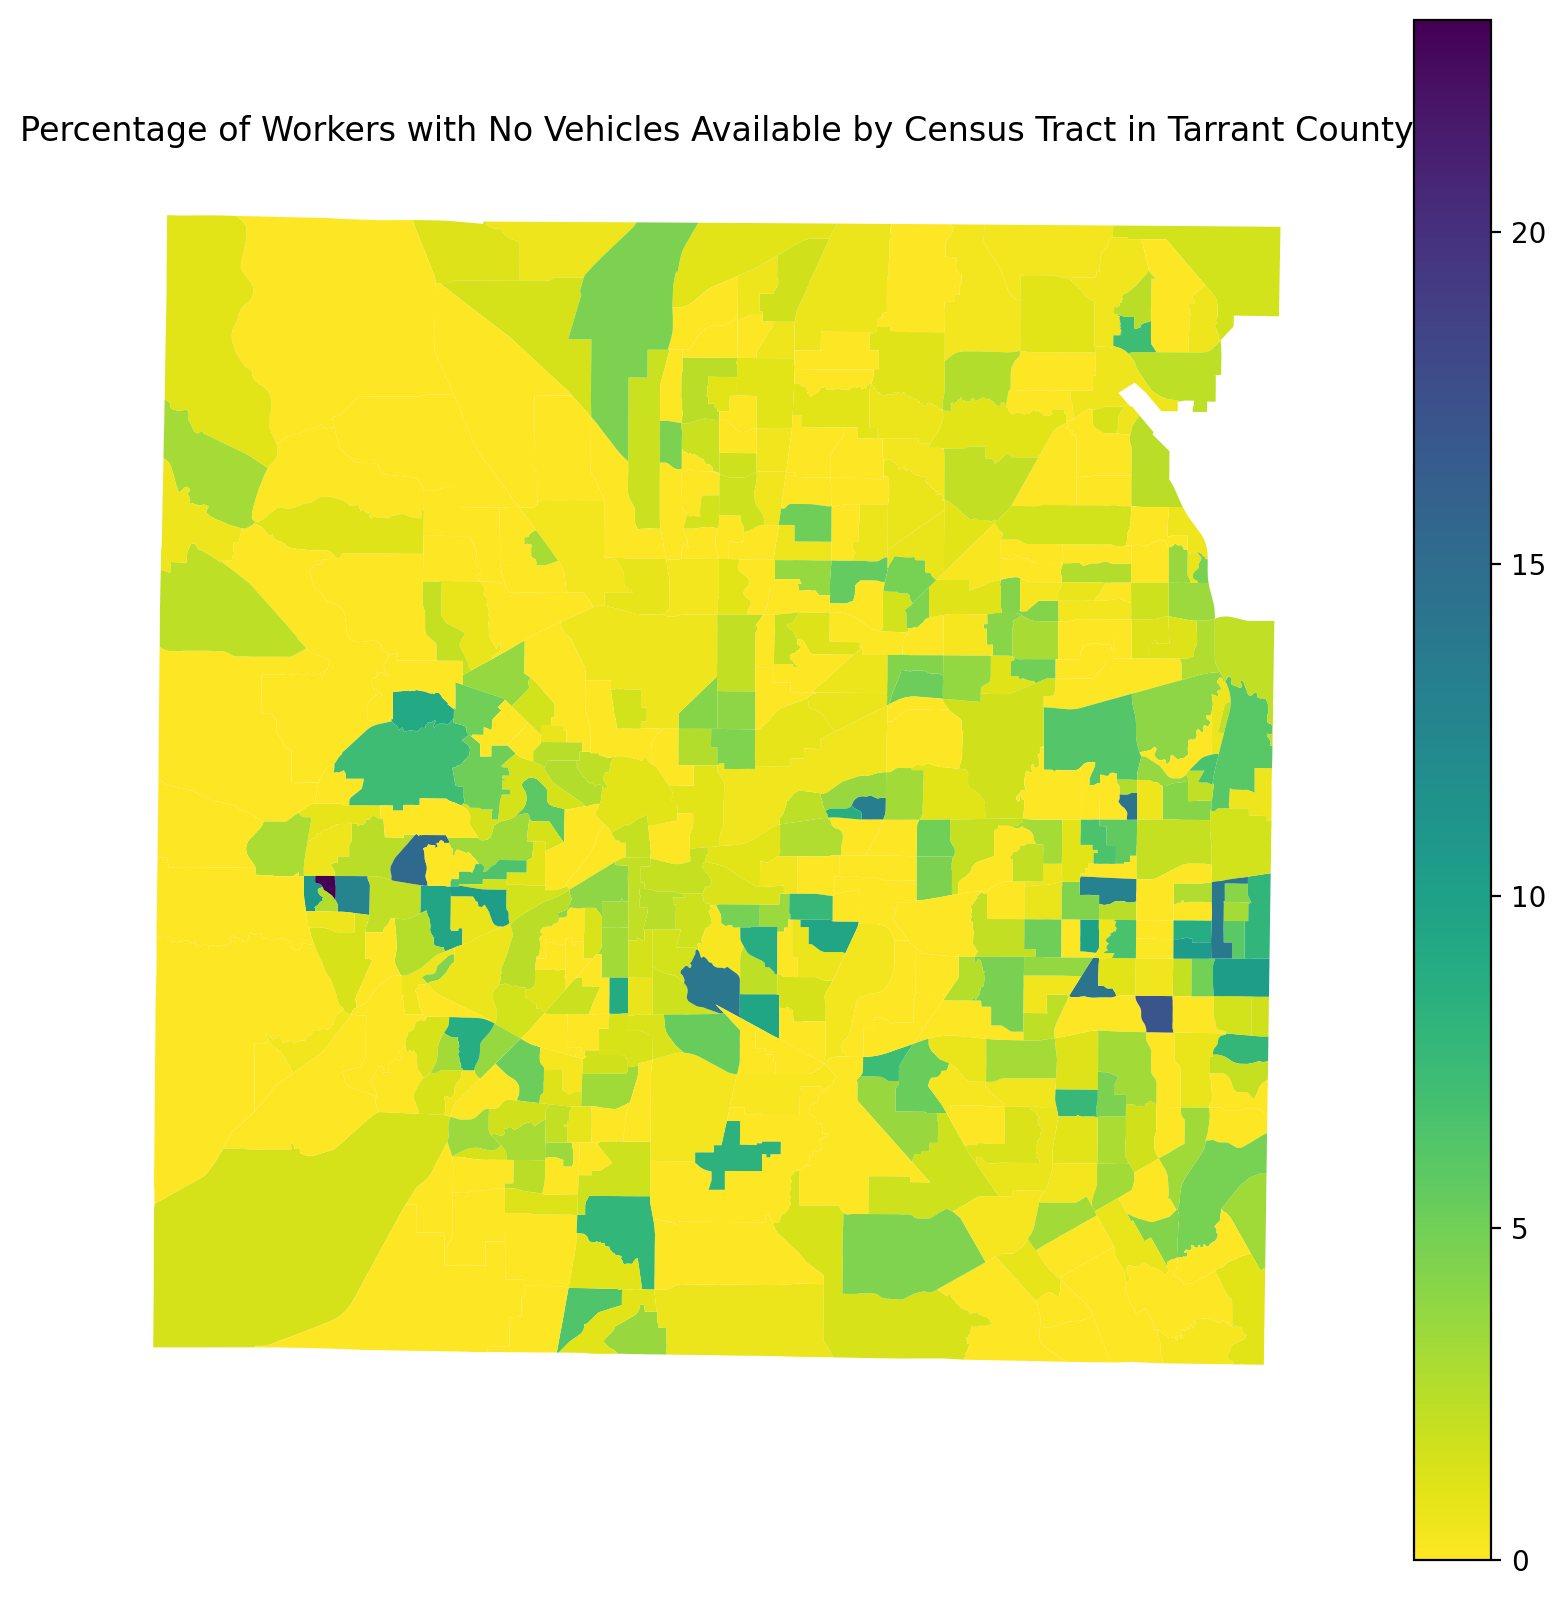

In [340]:
fig, ax = plt.subplots(figsize=(10, 10))

merged_2.plot(
    column="S0802_C01_094E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of Workers with No Vehicles Available by Census Tract in Tarrant County")
plt.axis("off")
plt.show()

# 3. SNAP Map

In [341]:
df = pd.read_csv('tarrant_snap_data.csv')
df

,GEO_ID,NAME,S2201_C01_001E,S2201_C01_001M,S2201_C01_002E,S2201_C01_002M,S2201_C01_003E,S2201_C01_003M,S2201_C01_004E,S2201_C01_004M,...,S2201_C06_034E,S2201_C06_034M,S2201_C06_035E,S2201_C06_035M,S2201_C06_036E,S2201_C06_036M,S2201_C06_037E,S2201_C06_037M,S2201_C06_038E,S2201_C06_038M
0,Geography,Geographic Area Name,Estimate!!Total!!Households,Margin of Error!!Total!!Households,Estimate!!Total!!Households!!With one or more ...,Margin of Error!!Total!!Households!!With one o...,Estimate!!Total!!Households!!No people in the ...,Margin of Error!!Total!!Households!!No people ...,Estimate!!Total!!Households!!Married-couple fa...,Margin of Error!!Total!!Households!!Married-co...,...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...
1,1400000US48439100101,Census Tract 1001.01; Tarrant County; Texas,1697,147,501,123,1196,186,694,176,...,(X),(X),(X),(X),16.7,9.8,22.9,10.7,60.4,13
2,1400000US48439100102,Census Tract 1001.02; Tarrant County; Texas,1914,192,431,83,1483,199,881,170,...,(X),(X),(X),(X),9.7,5.2,32.7,11.2,57.6,10.7
3,1400000US48439100201,Census Tract 1002.01; Tarrant County; Texas,1348,270,304,109,1044,292,644,147,...,(X),(X),(X),(X),3,4.2,35.4,14.1,61.6,13.9
4,1400000US48439100202,Census Tract 1002.02; Tarrant County; Texas,1395,154,512,156,883,136,751,173,...,(X),(X),(X),(X),12.3,11.5,25.1,11.3,62.6,13.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,1400000US48439123302,Census Tract 1233.02; Tarrant County; Texas,1554,208,453,85,1101,218,409,117,...,(X),(X),(X),(X),12,9.2,32.8,16.3,55.2,17.3
446,1400000US48439123500,Census Tract 1235; Tarrant County; Texas,876,152,275,86,601,150,364,107,...,(X),(X),(X),(X),7.2,5.4,44.1,17.4,48.6,17
447,1400000US48439123600,Census Tract 1236; Tarrant County; Texas,1998,200,457,143,1541,220,324,147,...,(X),(X),(X),(X),11.9,11.6,18.1,14.6,70,17.1
448,1400000US48439123700,Census Tract 1237; Tarrant County; Texas,1936,258,496,164,1440,259,777,202,...,(X),(X),(X),(X),3.6,4.5,24.9,12.7,71.5,13.8


In [342]:
merged_3 = tarrant.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [343]:
merged_3["S2201_C04_001E"] = pd.to_numeric(
    merged_3["S2201_C04_001E"],
    errors="coerce"
)

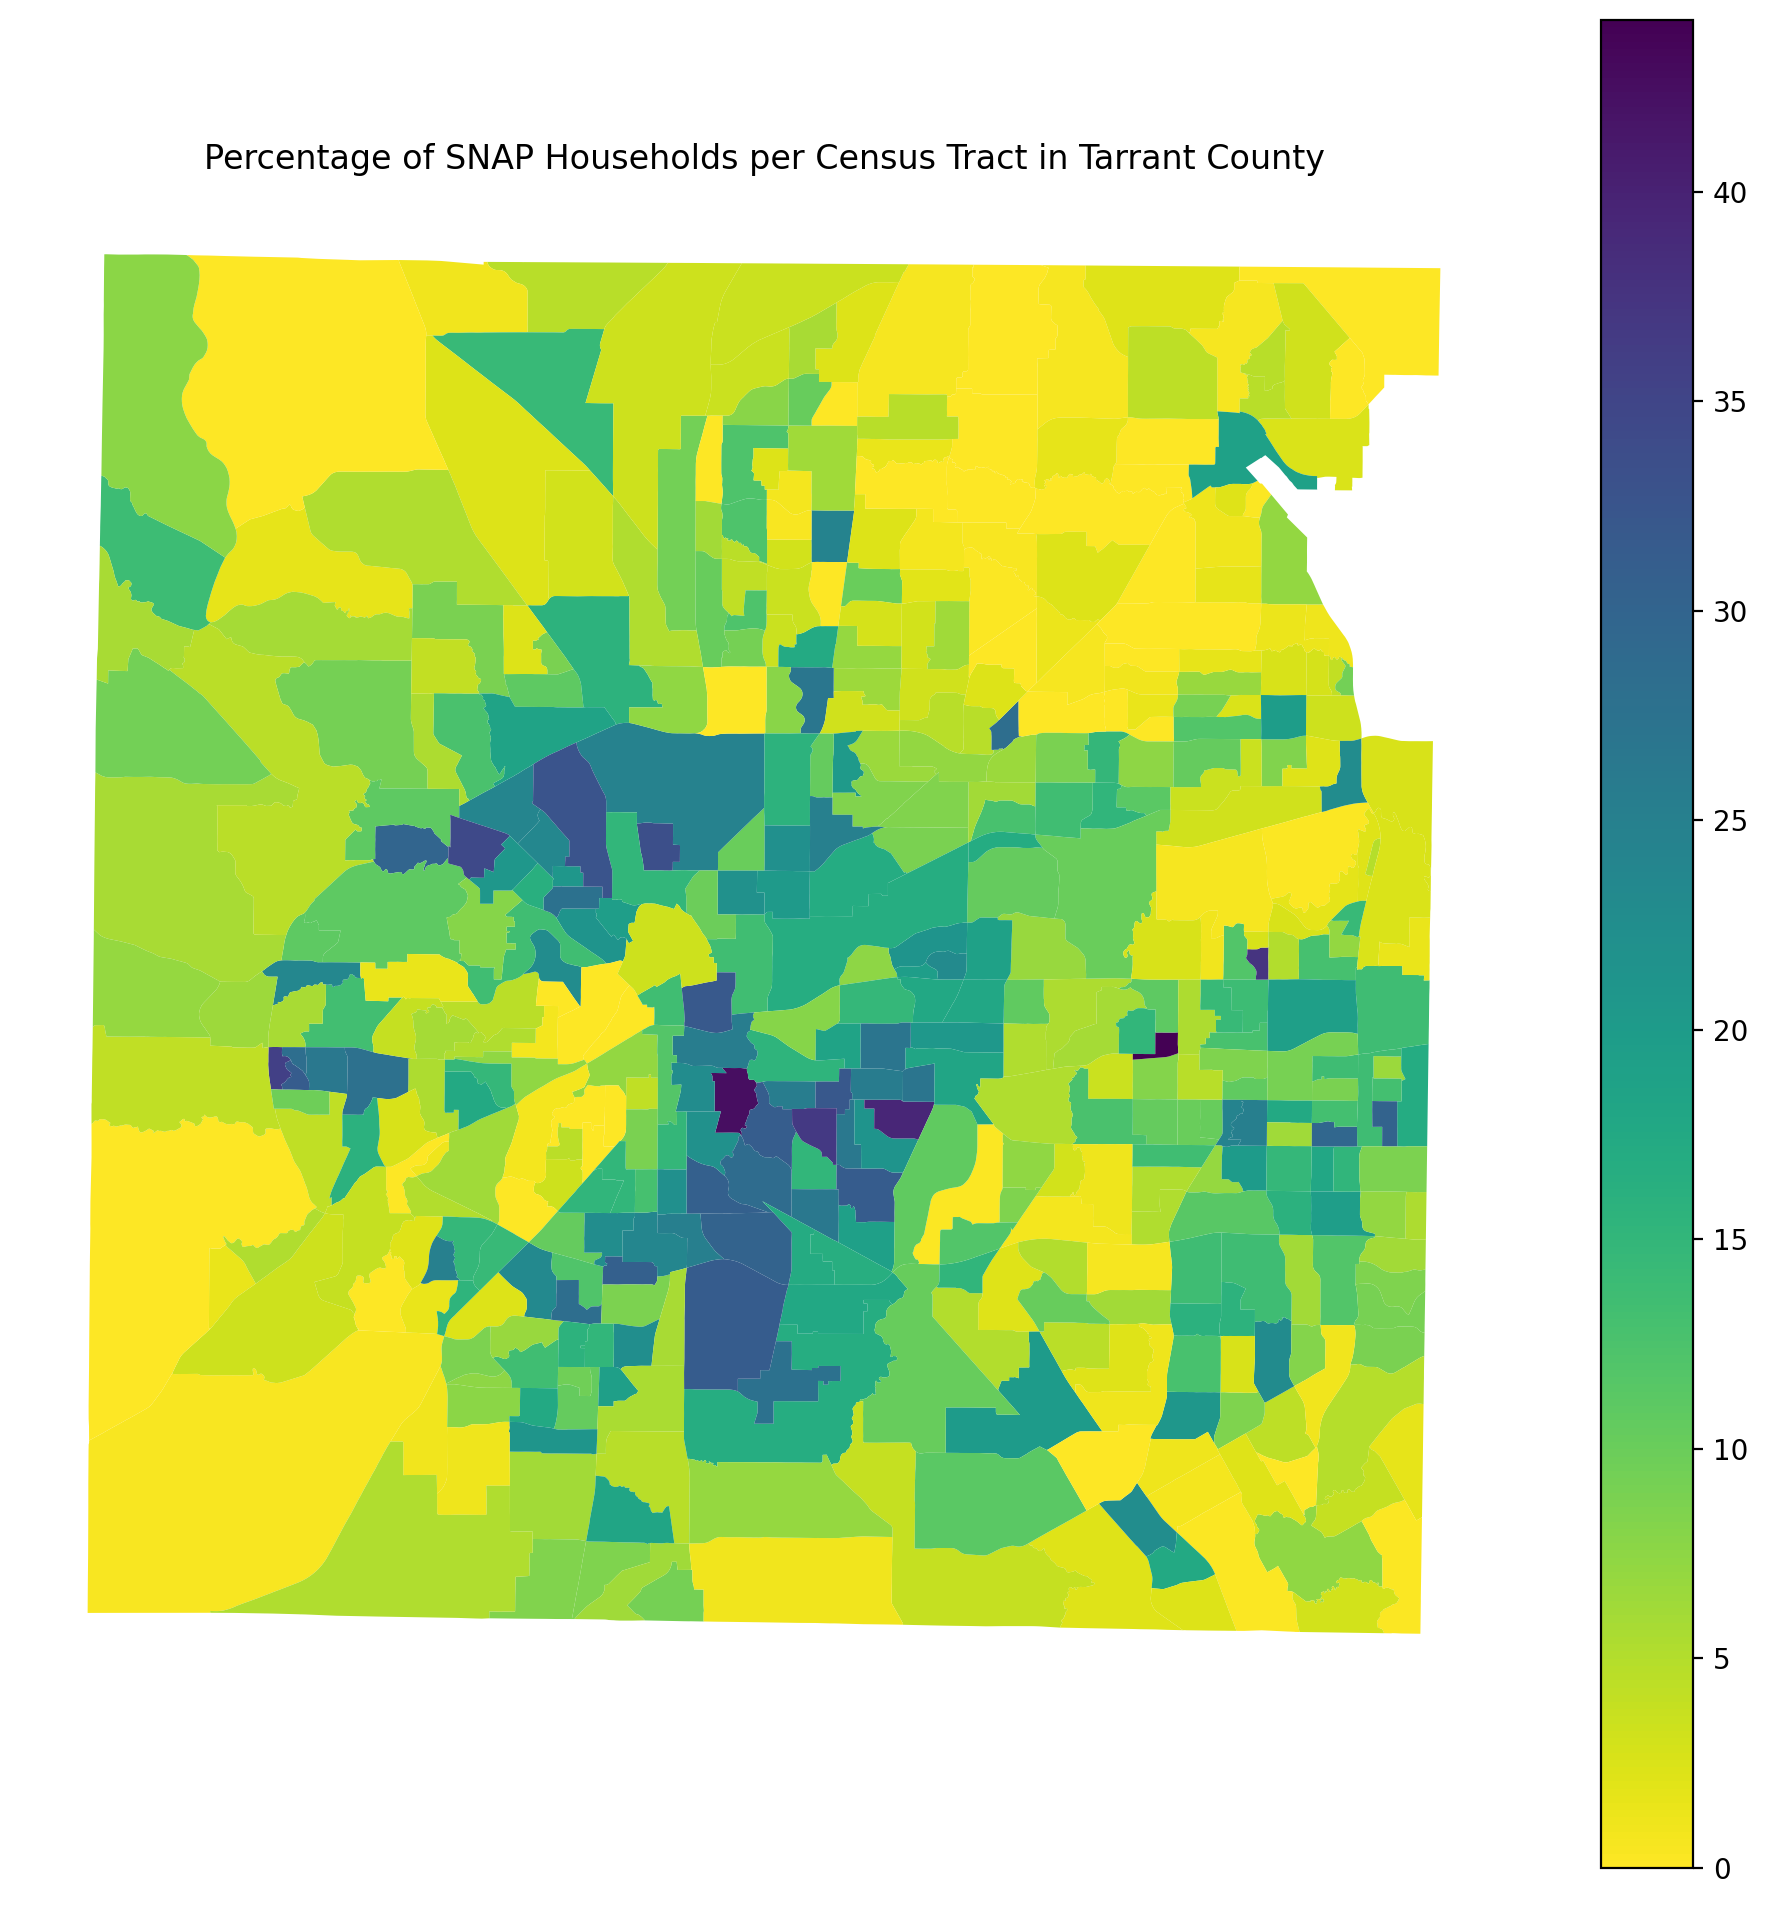

In [344]:
fig, ax = plt.subplots(figsize=(12, 12))

merged_3.plot(
    column="S2201_C04_001E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of SNAP Households per Census Tract in Tarrant County")
plt.axis("off")
plt.show()

# 4. Making Binary Variables

In [345]:
#State Median Income
#make sure column is numeric
merged["S1903_C03_001E"] = pd.to_numeric(
    merged["S1903_C03_001E"],
    errors="coerce"
)

#binary variable
merged["binary_income"] = (
    merged["S1903_C03_001E"] < 0.8*79721
).astype(int)
#1 if median income less than 0.8*79721
#0 if median income greater than or equal to 0.8*79721

In [346]:
merged["binary_income"]

0      0
1      0
2      0
3      0
4      0
      ..
444    1
445    0
446    1
447    1
448    0
Name: binary_income, Length: 449, dtype: int64

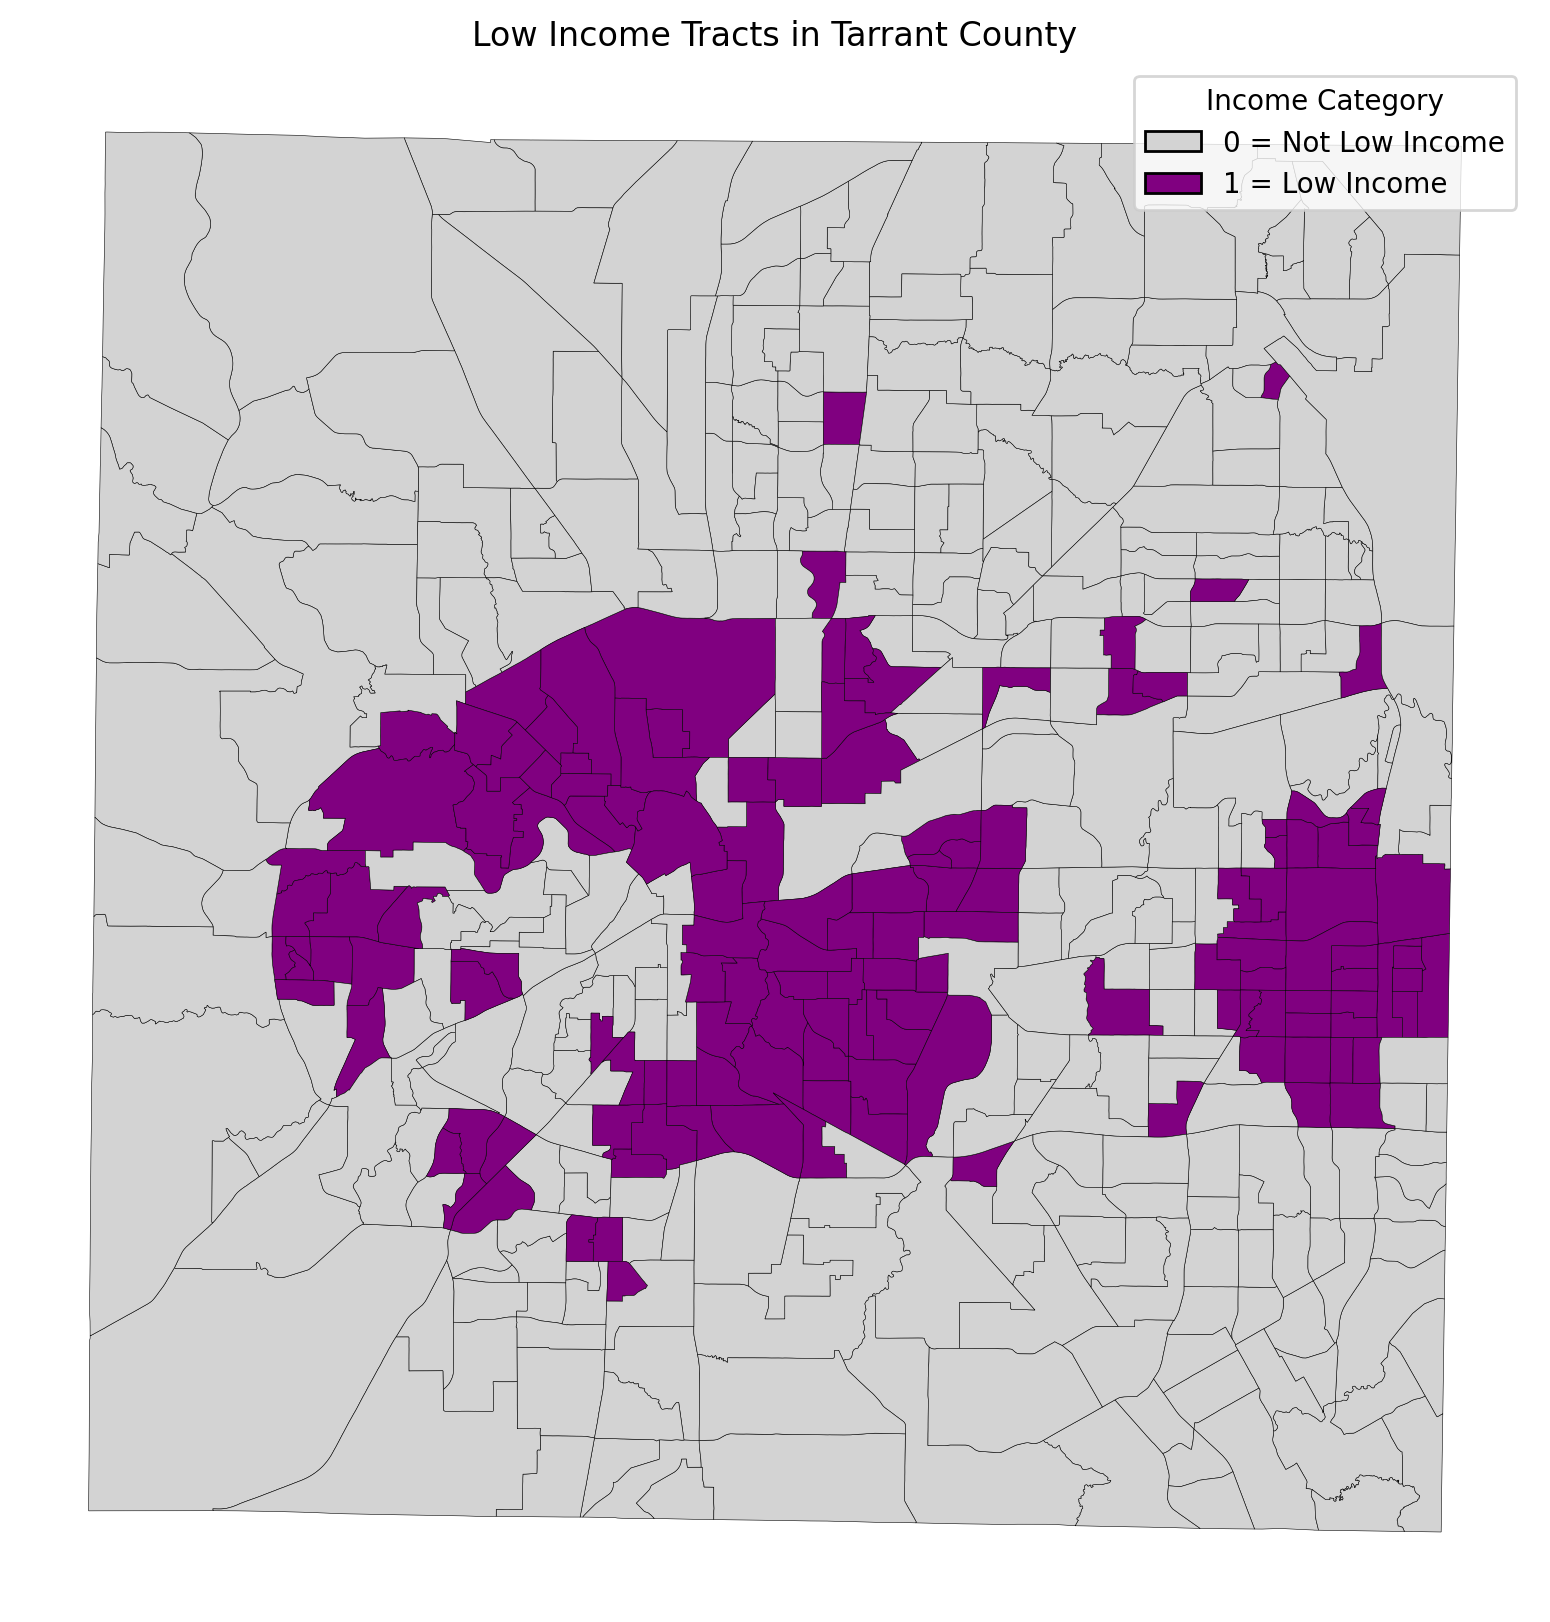

In [347]:
#low income according to state median income plot
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch 

cmap = ListedColormap(["lightgrey","Purple"])

fig, ax = plt.subplots(figsize=(10,10))

merged.plot(
    column="binary_income",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

legend_elements = [
    Patch(facecolor="lightgrey", edgecolor="black", label="0 = Not Low Income"),
    Patch(facecolor="purple", edgecolor="black", label="1 = Low Income")
]

ax.legend(handles=legend_elements, title="Income Category")

plt.title("Low Income Tracts in Tarrant County")
plt.axis("off")
plt.show()

# 5. Metropolitan Area Median Family Income

This map displays for each census tract that is in a metropolitan area that has a median income less than 80% of the metropolitan area's median income. The median income for the Tarrant Metropolitan Area for 2024 is $92,733.

In [348]:
import pandas as pd
df_2= pd.read_csv('tarrant_metropolitan.csv')

In [349]:
df_2

,GEO_ID,NAME,S1903_C01_001E,S1903_C01_001M,S1903_C01_002E,S1903_C01_002M,S1903_C01_003E,S1903_C01_003M,S1903_C01_004E,S1903_C01_004M,...,S1903_C03_036E,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M
0,Geography,Geographic Area Name,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...
1,310M700US19100,"Dallas-Fort Worth-Arlington, TX Metro Area",3012855,10622,1573847,12741,535238,9039,20731,3095,...,45778,1765,103547,4885,65023,2163,57936,3153,101704,5785


In [350]:
gdf = gpd.read_file("tl_2024_48_tract.shp")
tarrant = gdf[gdf["COUNTYFP"] == "439"]

In [351]:
#merging map and metropolitan file
merged_2 = tarrant.merge(
    df_2,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [352]:
merged_2["binary_income_2"] = (
    merged_2["S1903_C03_001E"] < 0.8*92733
).astype(int)

In [353]:
#make sure numbers numeric
merged_2["S1903_C03_001E"] = pd.to_numeric(
    merged_2["S1903_C03_001E"],
    errors="coerce"
)

# 6. Low-Income Tracts

In [354]:
df_poverty = pd.read_csv('tarrant_poverty_tracts.csv')
df_poverty

,GEO_ID,NAME,S1701_C01_001E,S1701_C01_001M,S1701_C01_002E,S1701_C01_002M,S1701_C01_003E,S1701_C01_003M,S1701_C01_004E,S1701_C01_004M,...,S1701_C03_058E,S1701_C03_058M,S1701_C03_059E,S1701_C03_059M,S1701_C03_060E,S1701_C03_060M,S1701_C03_061E,S1701_C03_061M,S1701_C03_062E,S1701_C03_062M
0,Geography,Geographic Area Name,Estimate!!Total!!Population for whom poverty s...,Margin of Error!!Total!!Population for whom po...,Estimate!!Total!!Population for whom poverty s...,Margin of Error!!Total!!Population for whom po...,Estimate!!Total!!Population for whom poverty s...,Margin of Error!!Total!!Population for whom po...,Estimate!!Total!!Population for whom poverty s...,Margin of Error!!Total!!Population for whom po...,...,Estimate!!Percent below poverty level!!UNRELAT...,Margin of Error!!Percent below poverty level!!...,Estimate!!Percent below poverty level!!UNRELAT...,Margin of Error!!Percent below poverty level!!...,Estimate!!Percent below poverty level!!UNRELAT...,Margin of Error!!Percent below poverty level!!...,Estimate!!Percent below poverty level!!UNRELAT...,Margin of Error!!Percent below poverty level!!...,Estimate!!Percent below poverty level!!UNRELAT...,Margin of Error!!Percent below poverty level!!...
1,1400000US48439100101,Census Tract 1001.01; Tarrant County; Texas,5165,640,1000,277,266,111,734,223,...,(X),(X),0,8.3,30.7,37.4,56.7,43.8,13.3,7.3
2,1400000US48439100102,Census Tract 1001.02; Tarrant County; Texas,5018,729,1164,512,234,202,930,436,...,(X),(X),3.9,4.4,54.5,16,73.6,34.1,14.5,6.8
3,1400000US48439100201,Census Tract 1002.01; Tarrant County; Texas,4912,1556,1829,1248,159,137,1670,1252,...,(X),(X),0,20.3,51.6,34,29.9,40.2,32.3,22.9
4,1400000US48439100202,Census Tract 1002.02; Tarrant County; Texas,4277,580,1121,360,106,77,1015,358,...,(X),(X),0,22.8,25,44.5,59.7,26.3,13.3,7.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,1400000US48439123302,Census Tract 1233.02; Tarrant County; Texas,2281,315,92,61,1,6,91,61,...,(X),(X),0,6.5,0,35,48.3,26.6,12.3,7.6
446,1400000US48439123500,Census Tract 1235; Tarrant County; Texas,3099,620,1003,348,270,120,733,284,...,(X),(X),3.8,6,0,66.1,82.3,18.4,21.8,12.5
447,1400000US48439123600,Census Tract 1236; Tarrant County; Texas,3806,574,462,269,71,80,391,248,...,(X),(X),1.7,1.9,17.9,13.8,53.8,15.6,22.2,10.7
448,1400000US48439123700,Census Tract 1237; Tarrant County; Texas,3886,625,722,238,285,169,437,155,...,(X),(X),3.6,5.5,36.1,24.3,36.5,21.1,11.1,6


In [355]:
#merging SHP file
merged_3 = tarrant.merge(
    df_poverty,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [356]:
#make sure values numeric
merged_3["S1701_C03_001E"] = pd.to_numeric(
    merged_3["S1701_C03_001E"],
    errors="coerce"
)

In [357]:
merged_3["binary_poverty"] = (
    merged_3["S1701_C03_001E"] >= 20.0
).astype(int)

# 7. Merging All Datasets

In [358]:
#make copy of binary columns in first dataframe 
combined = merged.copy()

combined["binary_income_2"] = merged_2["binary_income_2"].values
combined["binary_poverty"] = merged_3["binary_poverty"].values

#final USDA criterion
combined["binary_low_income"] = (
    (combined["binary_income"] == 1) |
    (combined["binary_income_2"] == 1) |
    (combined["binary_poverty"] == 1)
).astype(int)

#plot
combined.plot(
    column="binary_low_income",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

<Axes: title={'center': 'Low Income Tracts in Tarrant County'}>

In [359]:
#each condition as an or statement 
combined["binary_low_income"] = (
    (combined["binary_income"] == 1) |
    (combined["binary_income_2"] == 1) |
    (combined["binary_poverty"] == 1)
).astype(int)

In [360]:
combined.plot(
    column="binary_low_income",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

<Axes: title={'center': 'Low Income Tracts in Tarrant County'}>

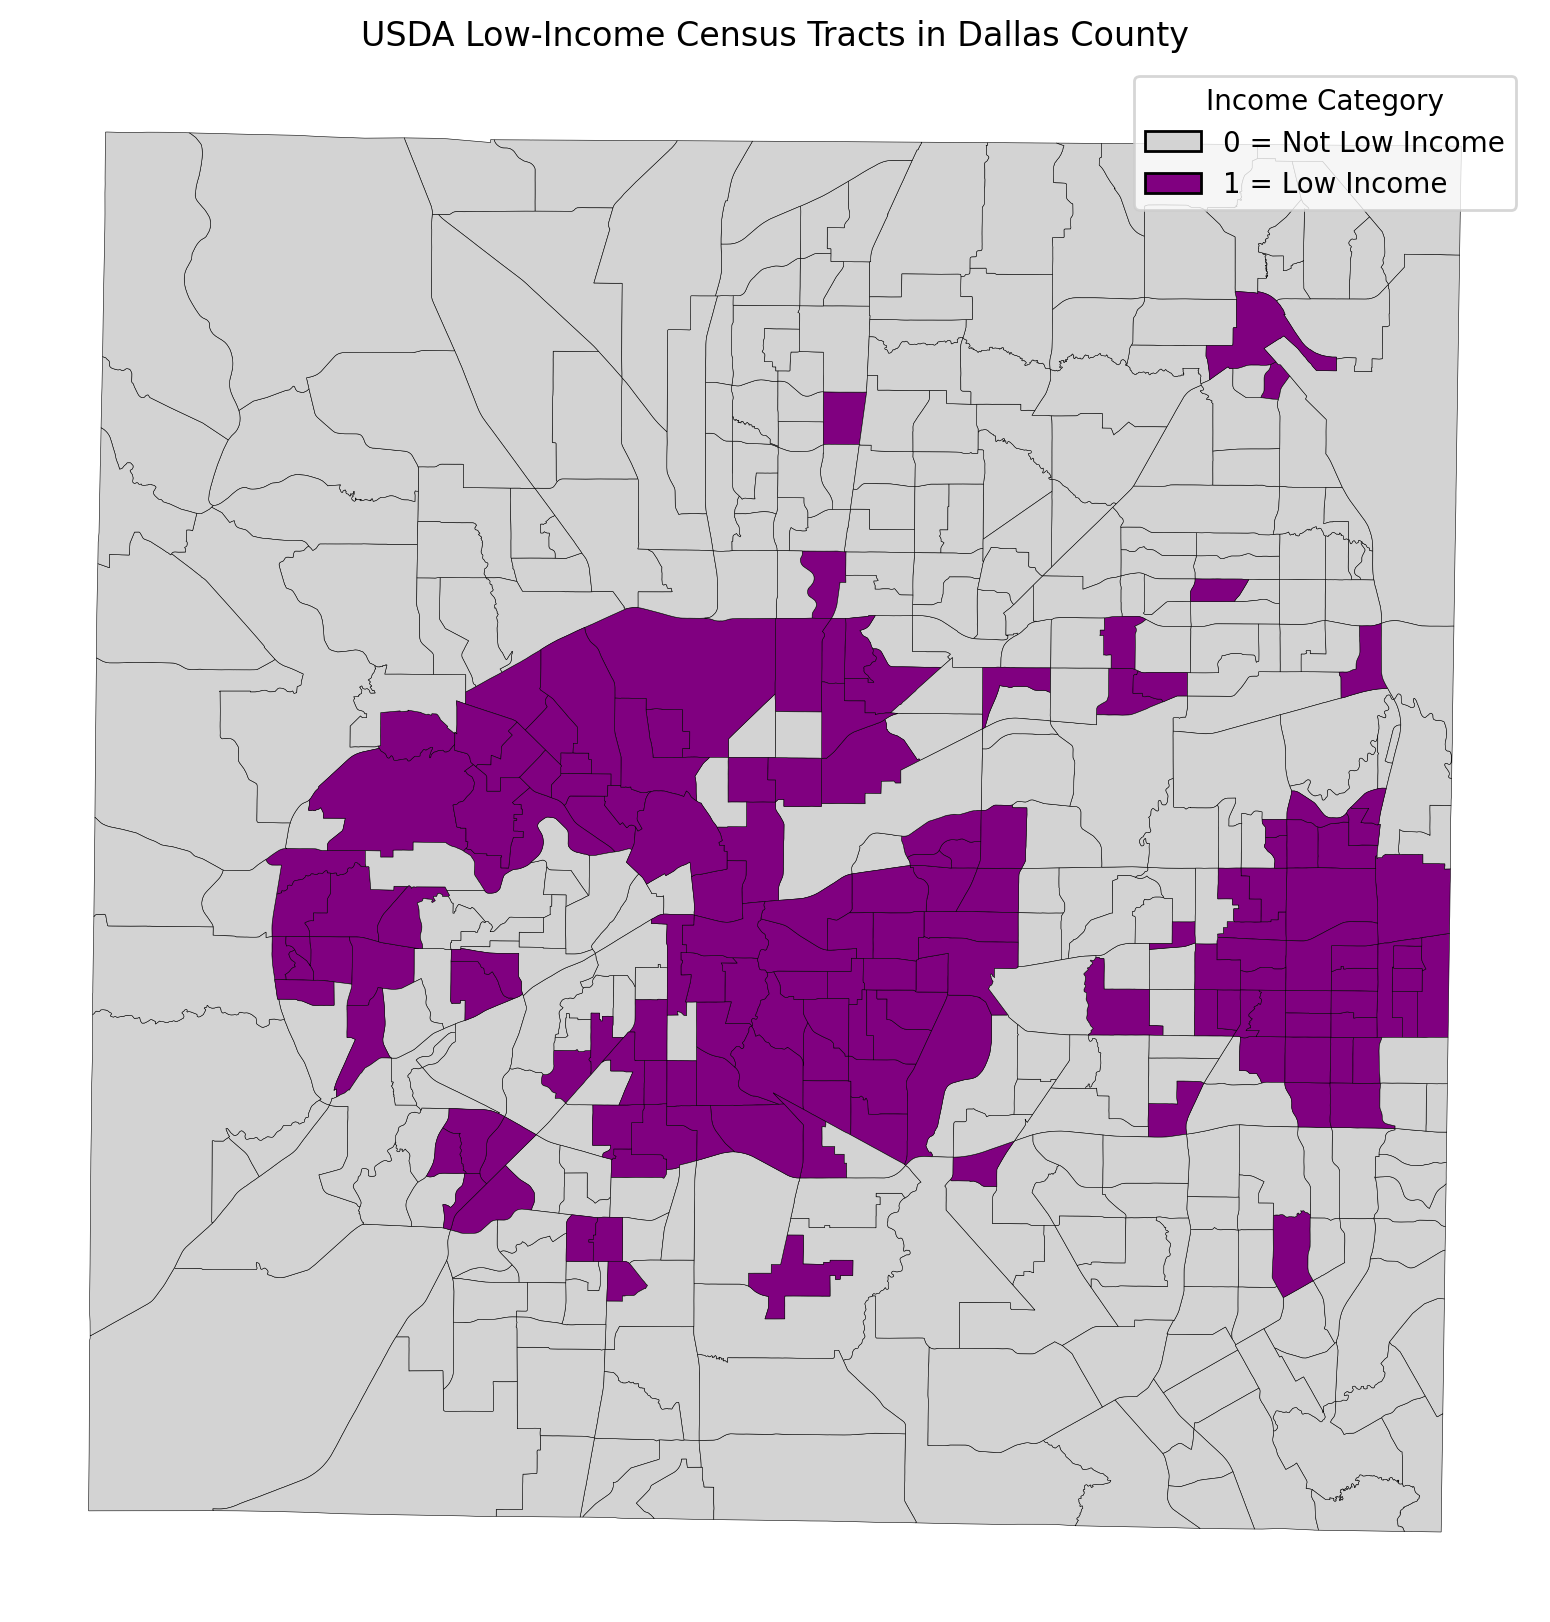

In [361]:
fig, ax = plt.subplots(figsize=(10, 10))

combined.plot(
    column="binary_low_income",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

legend_elements = [
    Patch(facecolor="lightgrey", edgecolor="black", label="0 = Not Low Income"),
    Patch(facecolor="purple", edgecolor="black", label="1 = Low Income")
]

ax.legend(handles=legend_elements, title="Income Category")
plt.title("USDA Low-Income Census Tracts in Dallas County")
plt.axis("off")
plt.show()

# 8. Importing SNAP Data

In [362]:
# filter by state and county (Harris County, TX)

df = pd.read_csv("snap_retailer_location_data.csv")
tarrant_snap = df[(df["State"]== "TX") & (df["County"]=="TARRANT")]

print(tarrant_snap.shape)
print(tarrant_snap["Store_Type"].value_counts())

# want to exclude Dollar General, Dollar Tree, CVS Pharmacy, CVS, Family Dollar,  Walgreens

excluded_others=["Dollar", "CVS", "Walgreen", "Walgrens", "Pharmacy"]

new_tarrant_data = tarrant_snap[(tarrant_snap["Store_Type"] == "Other") 
    & ~tarrant_snap["Store_Name"].str.contains("|".join(excluded_others), case=False, na=False)].copy()
print(new_tarrant_data.shape)
print(new_tarrant_data["Store_Name"].unique())

# I also excluded any place that said closed on google maps
kept_tarrant_others = ["Lusu African Market", "FARMERS MARKET OF FT WORTH", "El Tapatio Meat Market I", "Bombay Bazaar", "Ocean Seafood Market",
                     "The Joseph Storehouse", "Lmmm Dallas 15 Ltd. 15", "Anastasie African Store", "New Diamond Grocery", "African Heritage Market", "African Union Market"
                     , "Blessing African Store", "Shadai Group African Market","La Michoacana Meat Market", "Spice And Slice Bazaar", "Lizzy's African Market",
                     "Charme Market", "Akabanga International Market", "Namaste Grocery", "El Mercadito Supermarket Inc", "Favor African Market Llc", "La Michoacana Meat Market D22" ]

excluded_tarrant_others = ["Taleeh Grocery", "Guanajuato Bakery", "Shukrani Market Inc'", "Demcy African Market", "Mire's Market", "Leelah African Store"
                          ,"Afro Mart", "Dgs Exotic Marke","Nath Beauty Collection And African Store", "Gloesis Group","A&E International Market",
                         "Lifeland Market Llc", "Md Divine Supermarket", "Jm Farm Market", "Afriq All Collection", "African Pride Food Store" ]

# filter out stores that are not grocery stores
included = ["Super Store","Supermarket","Grocery Store", "Farmers and Markets"]

cleaned_snap_data = tarrant_snap[tarrant_snap["Store_Type"].isin(included) | 
    tarrant_snap["Store_Name"].isin(kept_tarrant_others)| 
    tarrant_snap["Store_Name"].str.contains("Braum", case=False, na=False)].copy()

# remove columns that are not needed :"Additonal_Address", "Incentive_Program", "Grantee_Name", "X", "Y"

final_cleaned_snap_data = cleaned_snap_data.drop(columns=["Additonal_Address", "Incentive_Program", "Grantee_Name", "X", "Y", "Zip4"])

# Check for duplicate store names at the same address
dupes = final_cleaned_snap_data[cleaned_snap_data.duplicated(subset=["Store_Name", "Store_Street_Address"], keep=False)]
print(dupes[["Store_Name", "Store_Street_Address"]])

# final csv file created
final_cleaned_snap_data.to_csv("cleaned_tarrant_snap_data.csv", index=False)
print(final_cleaned_snap_data.shape)
print(final_cleaned_snap_data[["Store_Name", "Latitude", "Longitude", "Store_Type"]].head())


(1388, 17)
Store_Type
Convenience Store      685
Other                  357
Super Store            130
Grocery Store           97
Supermarket             96
Specialty Store         14
Farmers and Markets      9
Name: count, dtype: int64
(63, 17)
<StringArray>
[                     'Lusu African Market',
               'FARMERS MARKET OF FT WORTH',
                               'BRAUM'S 70',
                               'BRAUM'S 74',
                               'BRAUM'S 81',
                               'BRAUM'S 84',
                              'BRAUM'S 124',
                              'Braum's 128',
                              'BRAUM'S 130',
                              'BRAUM'S 165',
                              'BRAUM'S 194',
                              'BRAUM'S 199',
                              'BRAUM'S 200',
                              'BRAUM'S 202',
                              'BRAUM'S 210',
                              'BRAUM'S 215',
                    

Mapping

In [363]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

%matplotlib inline

# read CSV
df = pd.read_csv("cleaned_tarrant_snap_data.csv")

# make sure longitude/latitude are numeric
df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")

# remove rows with missing coordinates
df = df.dropna(subset=["Longitude", "Latitude"])

# create GeoDataFrame
geo_df = gpd.GeoDataFrame(
    df[[
        "Store_Name",
        "Store_Street_Address",
        "City",
        "Zip_Code",
        "Store_Type",
        "Latitude",
        "Longitude"
    ]],
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
)

geo_df.head()

,Store_Name,Store_Street_Address,City,Zip_Code,Store_Type,Latitude,Longitude,geometry
0,Iyanu African Caribbean Marketplace,2154 N Collins St,Arlington,76011,Grocery Store,32.768894,-97.098106,POINT (-97.09811 32.76889)
1,Sana Restaurant And Halal Grocery,5941 Watauga Rd,Watauga,76148,Grocery Store,32.861015,-97.252441,POINT (-97.25244 32.86102)
2,Victory Tropical Market Inc,415 N Main St,Euless,76039,Grocery Store,32.842609,-97.082672,POINT (-97.08267 32.84261)
3,Whole Foods Market 10098,801 E Lamar Blvd,Arlington,76011,Super Store,32.766853,-97.099075,POINT (-97.09908 32.76685)
4,Target Store 1765,8000 Denton Hwy,Watauga,76148,Super Store,32.889248,-97.256554,POINT (-97.25655 32.88925)


In [364]:
tarrant = gpd.read_file("tl_2024_48_tract.shp")

(449, 14)


<Axes: >

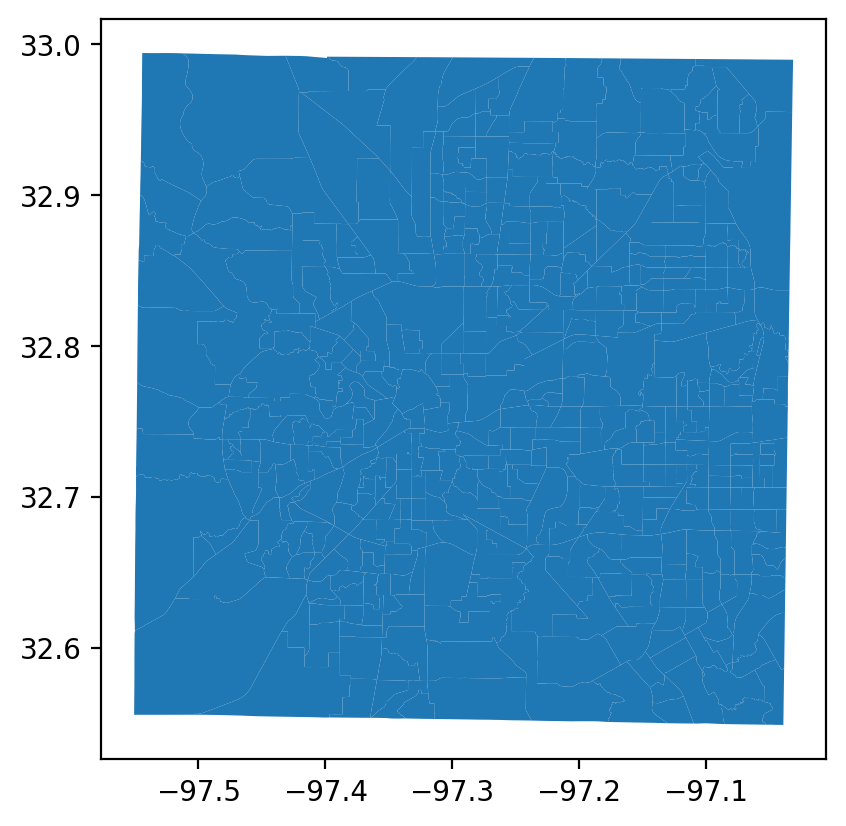

In [365]:
tarrant = tarrant[tarrant["COUNTYFP"] == "439"]

print(tarrant.shape)
tarrant.plot()

In [366]:
tarrant = tarrant[tarrant["COUNTYFP"] == "439"]

In [367]:
# convert my data to Web Mercator because it matches the mapping data we are using from contexitly
tarrant_wm = tarrant.to_crs(epsg=3857)
geo_df_wm = geo_df.to_crs(epsg=3857)

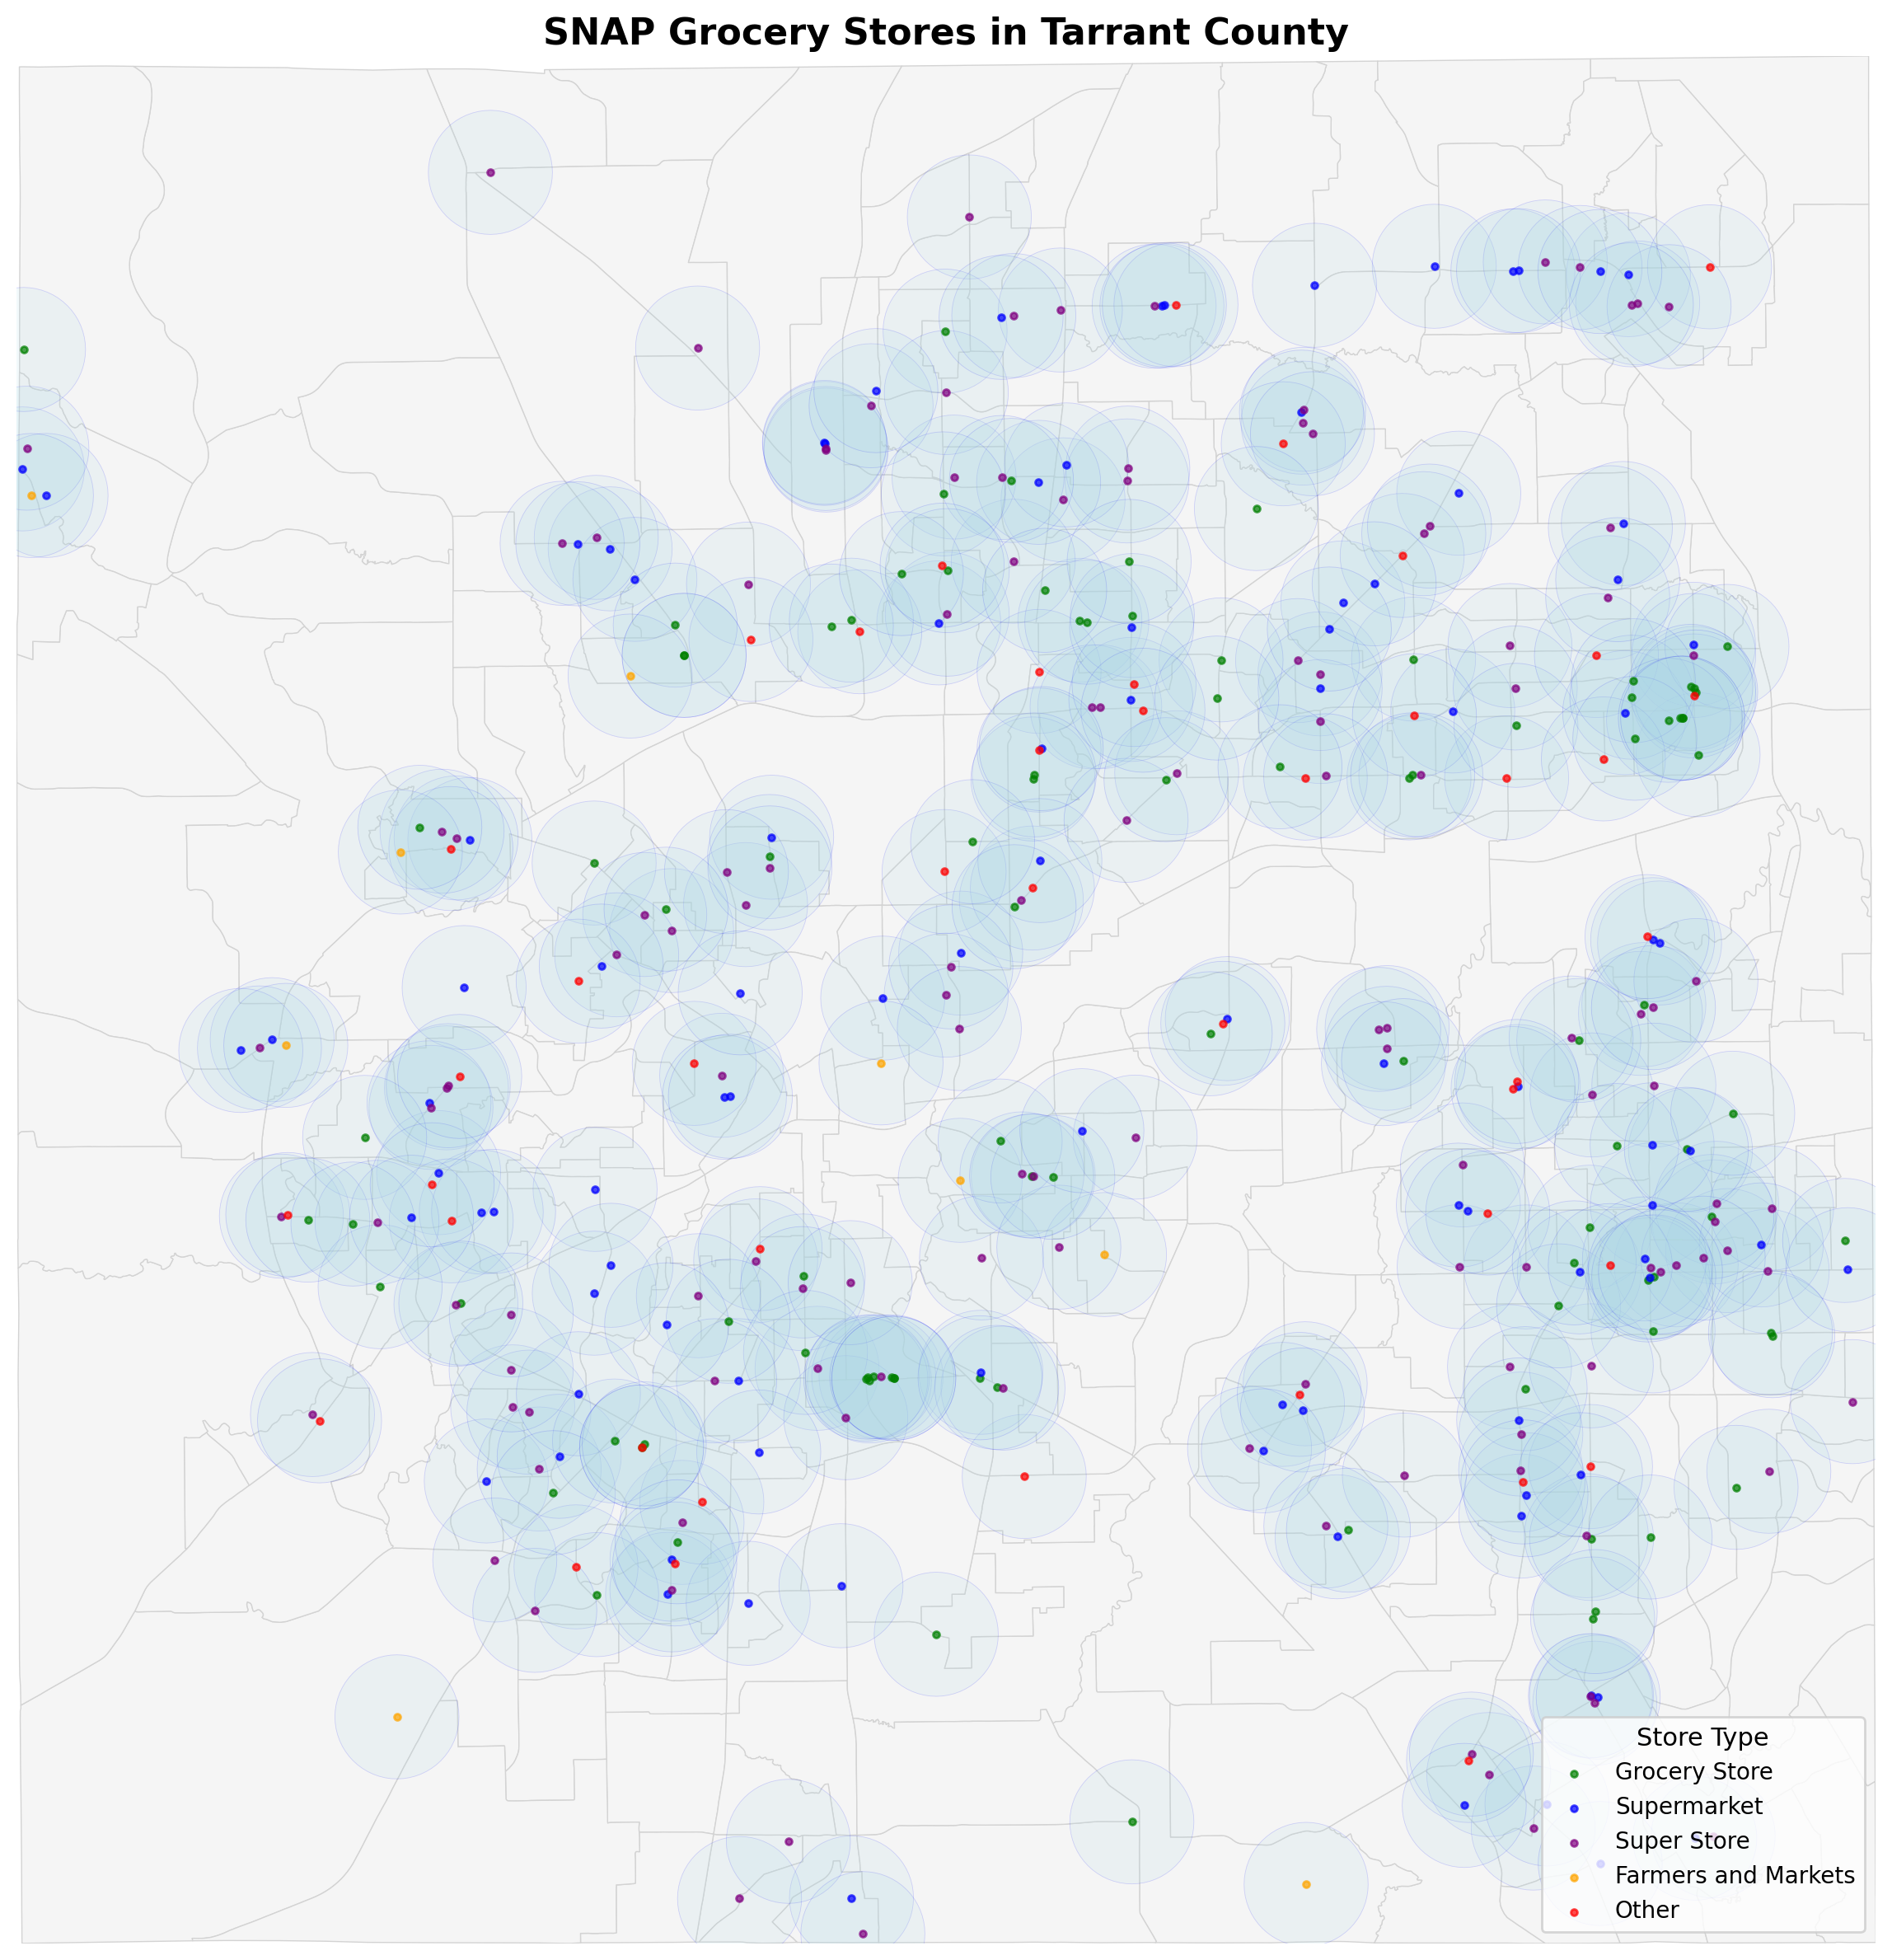

In [368]:
# convert to the right coordinate format
geo_df_projected = geo_df.to_crs(epsg=32614)
tarrant_projected = tarrant.to_crs(epsg=32614)

# create buffers
geo_df_buffer = geo_df_projected.copy()
geo_df_buffer["geometry"] = geo_df_projected.geometry.buffer(1609)

colors = {
    "Grocery Store": "green",
    "Supermarket": "blue",
    "Super Store": "purple",
    "Farmers and Markets": "orange",
    "Other": "red"
}

fig, ax = plt.subplots(figsize=(14, 12))

# project both graphs
tarrant_projected.plot(ax=ax, color="whitesmoke", edgecolor="lightgrey", linewidth=0.5)
geo_df_buffer.plot(ax=ax, color="lightblue", alpha=0.15, edgecolor="blue", linewidth=0.3)

for store_type, color in colors.items():
    subset = geo_df_projected[geo_df_projected["Store_Type"] == store_type]
    subset.plot(ax=ax, marker='o', color=color, markersize=8, alpha=0.7, label=store_type)

# legend 
ax.set_xlim(tarrant_projected.total_bounds[[0, 2]])
ax.set_ylim(tarrant_projected.total_bounds[[1, 3]])

ax.legend(title="Store Type", fontsize=10, title_fontsize=11, loc="lower right")
ax.axis("off")
ax.set_title("SNAP Grocery Stores in Tarrant County", fontsize=16, fontweight="bold", pad=5)
plt.tight_layout()
plt.show()

In [369]:
import os
print(os.listdir("."))

['cleaned_tarrant_snap_data.csv', 'clean_tarrant_snap_data.ipynb', 'mapping_tarrant_snap.ipynb', 'snap_retailer_location_data.csv', 'tarrantcountyanalysis.ipynb', 'tarrantmobility_columnnames.csv', 'tarrantmobility_data.csv', 'tarrantmobility_tablenotes.txt', 'tarrant_heat_maps.ipynb', 'tarrant_heat_maps_updated.ipynb', 'tarrant_income.csv', 'tarrant_income_column_names.csv', 'tarrant_income_notes.txt', 'tarrant_metropolitan.csv', 'tarrant_metropolitan_income.csv', 'tarrant_poverty_tracts.csv', 'tarrant_SNAP_data.csv', 'tarrant_SNAP_data_column_names.csv', 'tarrant_SNAP_data_notes.txt', 'Tarrant_snap_map.png', 'tl_2024_48_tract.cpg', 'tl_2024_48_tract.dbf', 'tl_2024_48_tract.prj', 'tl_2024_48_tract.shp', 'tl_2024_48_tract.shp.ea.iso.xml', 'tl_2024_48_tract.shp.iso.xml', 'tl_2024_48_tract.shx']


In [371]:
#import needed libraries
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# make grocery store points from longitude and latitude
stores = gpd.GeoDataFrame(
    final_cleaned_snap_data,
    geometry=gpd.points_from_xy(
        final_cleaned_snap_data["Longitude"],
        final_cleaned_snap_data["Latitude"]
    ),
    crs="EPSG:4326"
)

# make sure tract map has a coordinate system
merged = merged.set_crs("EPSG:4269", allow_override=True)

# 3 convert both into meters for distance calculations
tracts_m = merged.to_crs("EPSG:3857")
stores_m = stores.to_crs("EPSG:3857")

# get tract centroids
tracts_m["centroid"] = tracts_m.geometry.centroid
centroids = tracts_m.set_geometry("centroid")

# find nearest grocery store to each tract centroid with join_nearest function
nearest = gpd.sjoin_nearest(
    centroids,
    stores_m[["Store_Name", "geometry"]],
    how="left",
    distance_col="distance_meters"
)

# convert meters to miles
nearest["distance_miles"] = nearest["distance_meters"] / 1609.34

In [372]:
nearest = nearest.sort_values("distance_meters").drop_duplicates("GEOID")

low_access_map = merged.merge(
    nearest[["GEOID", "distance_miles"]],
    on="GEOID",
    how="left"
)

low_access_map["binary_low_access"] = (
    low_access_map["distance_miles"] > 1
).astype(int)

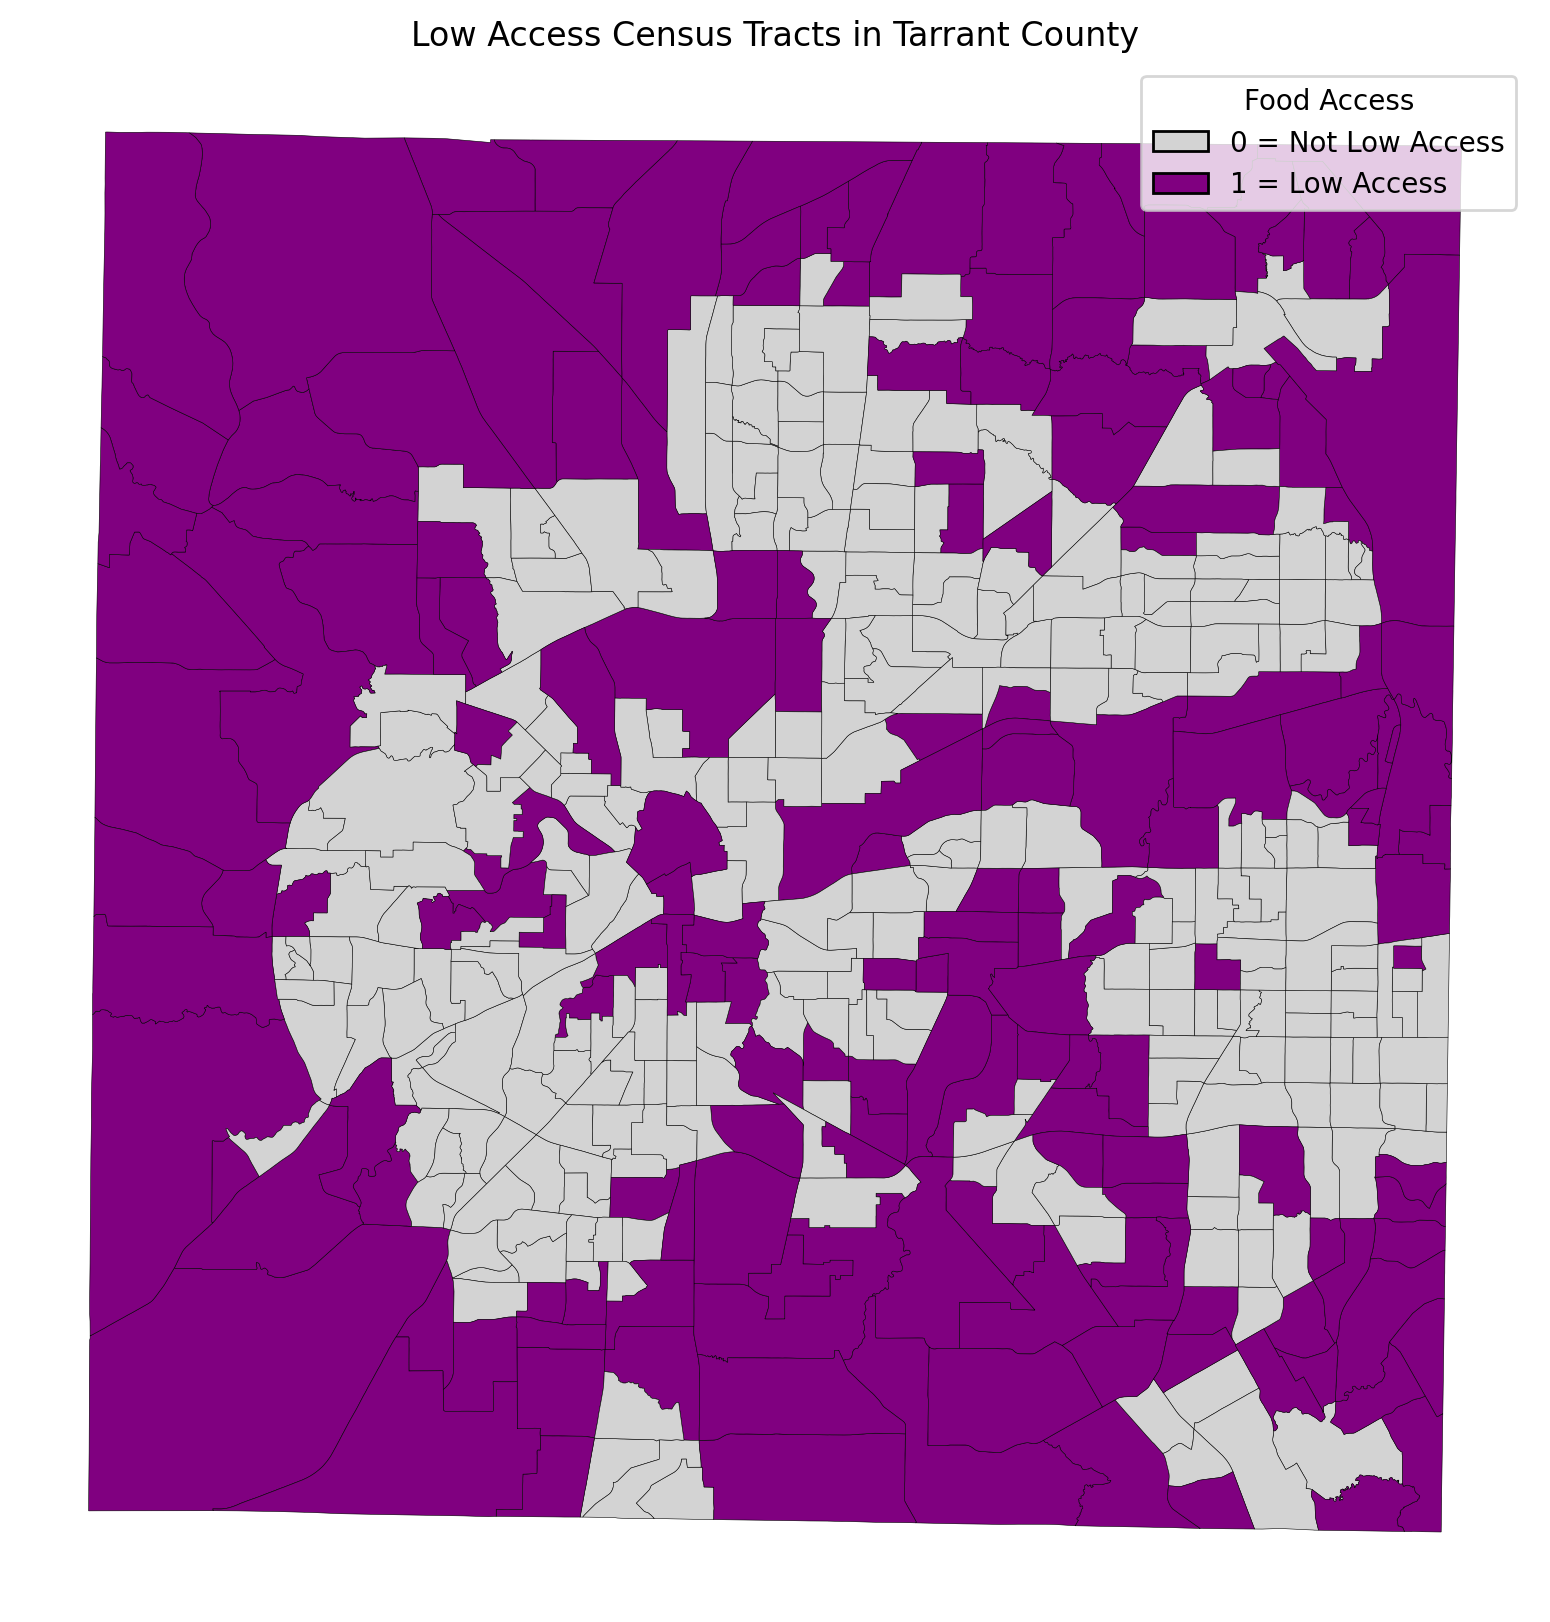

In [374]:
#map

cmap = ListedColormap(["lightgrey", "purple"])

fig, ax = plt.subplots(figsize=(10, 10))

low_access_map.plot(
    column="binary_low_access",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

legend_elements = [
    Patch(facecolor="lightgrey", edgecolor="black", label="0 = Not Low Access"),
    Patch(facecolor="purple", edgecolor="black", label="1 = Low Access")
]

ax.legend(handles=legend_elements, title="Food Access")
plt.title("Low Access Census Tracts in Tarrant County")
plt.axis("off")
plt.show()

# 9. Low Access and Low Income Census Map

This analysis approximates the USDA Food Access Research Atlas methodology. The USDA calculates low access using population-weighted 0.5-kilometer grid cells to determine how many people live beyond a specified distance from the nearest supermarket. Because these grid-level data are not available in the ACS tract-level data used in this project, low access was approximated by measuring the distance from each census tract centroid to the nearest grocery store. As a result, the map should be interpreted as an approximation rather than an exact replication of the USDA methodology.

In [375]:
#merge two datasets
final_map = combined.merge(
    low_access_map[["GEOID","binary_low_access"]],
    on="GEOID",
    how="left"
)

In [376]:
#conditional AND statement food desert indicator (low income and low access)
final_map["food_desert"] = (
    (final_map["binary_low_income"] == 1) & 
    (final_map["binary_low_access"] == 1)
)

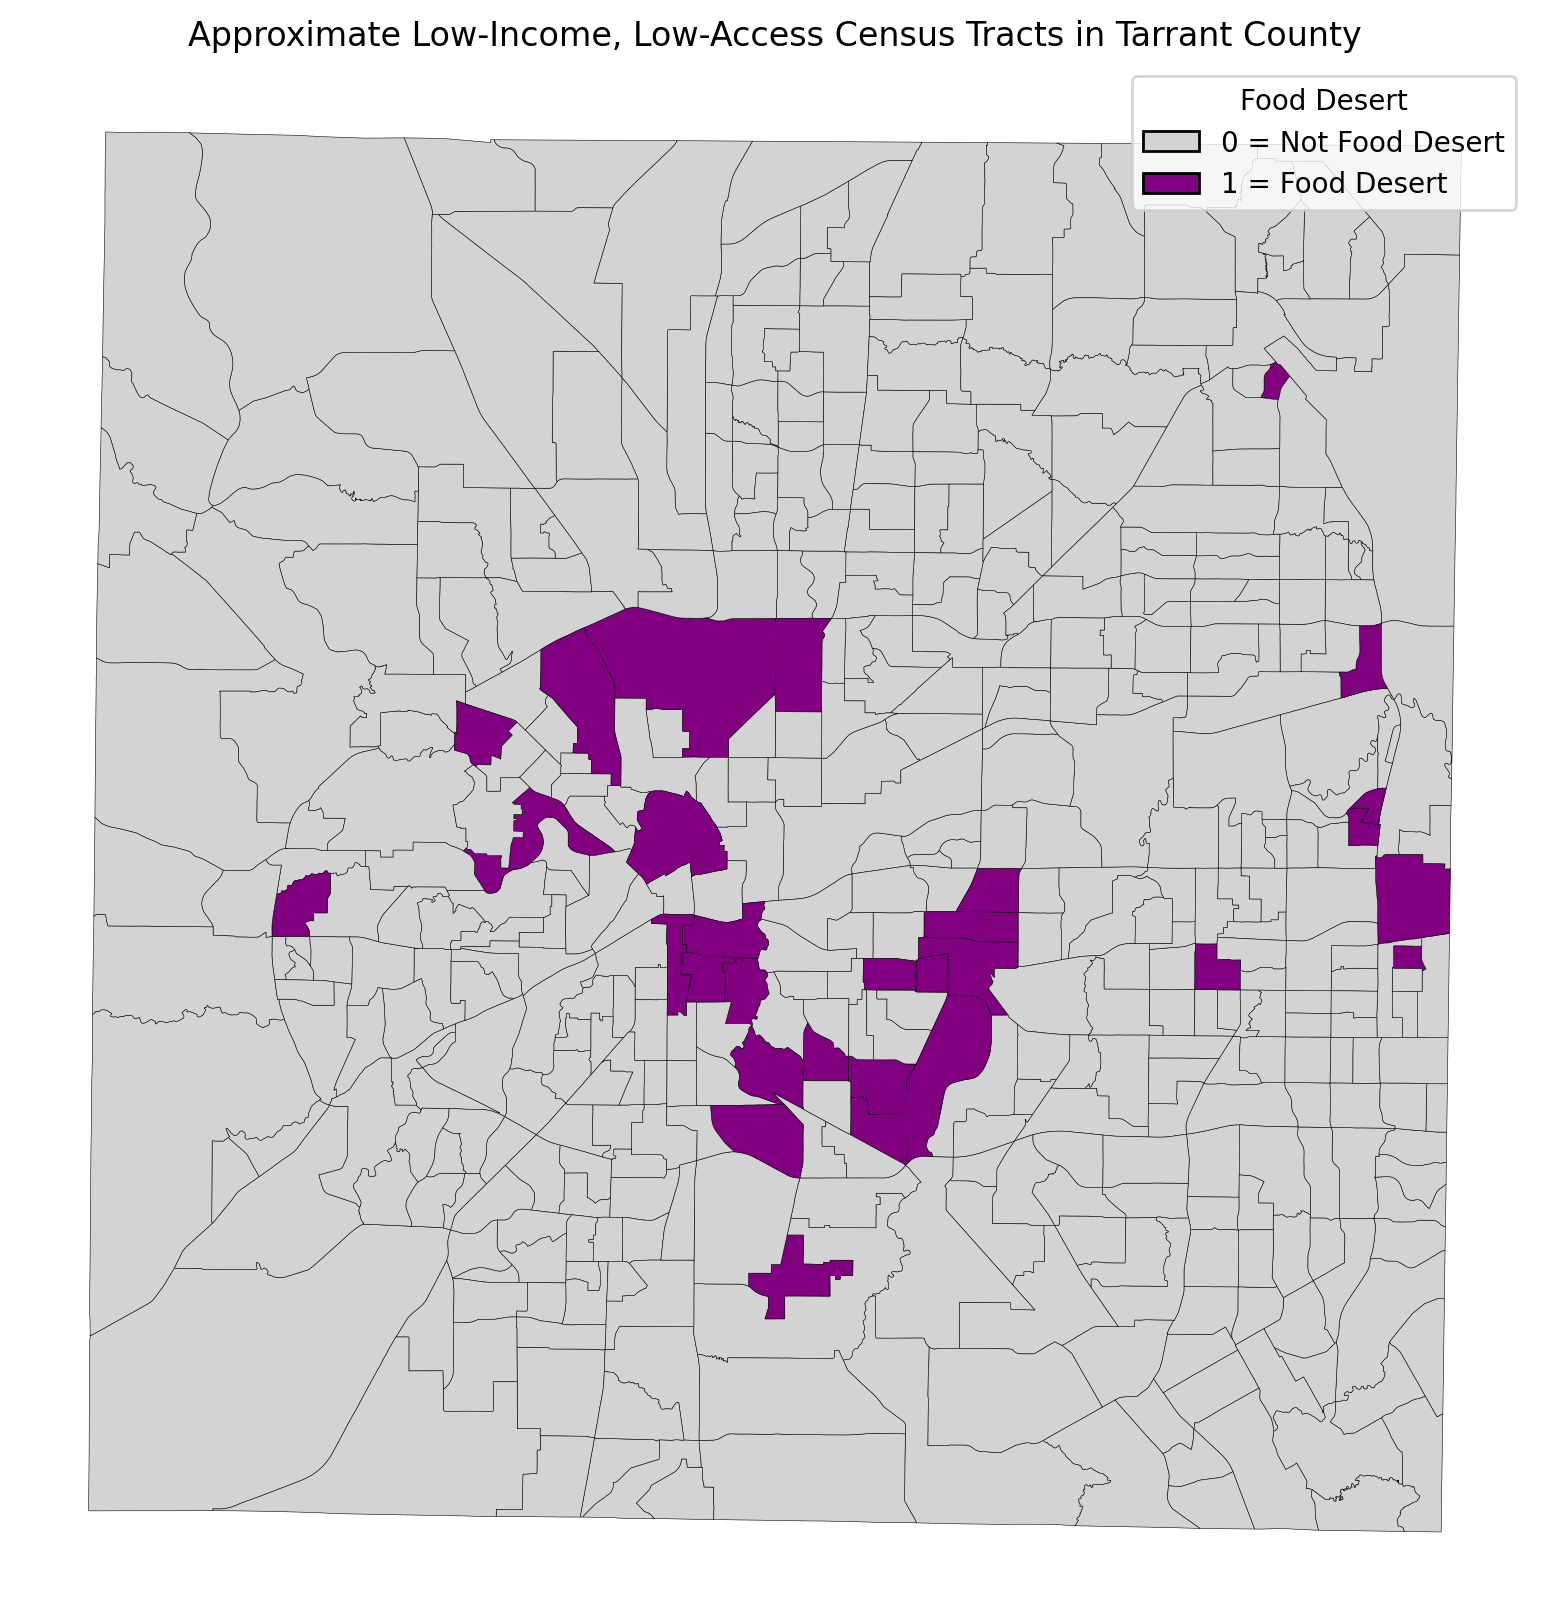

In [379]:
#binary map
fig, ax = plt.subplots(figsize=(10,10))

final_map.plot(
    column = "food_desert",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

#making a legend

legend_elements = [
    Patch(facecolor="lightgrey", edgecolor="black", label="0 = Not Food Desert"),
    Patch(facecolor="purple", edgecolor="black", label="1 = Food Desert")
]

ax.legend(handles=legend_elements, title="Food Desert")
plt.title("Approximate Low-Income, Low-Access Census Tracts in Tarrant County")
plt.axis("off")
plt.show()